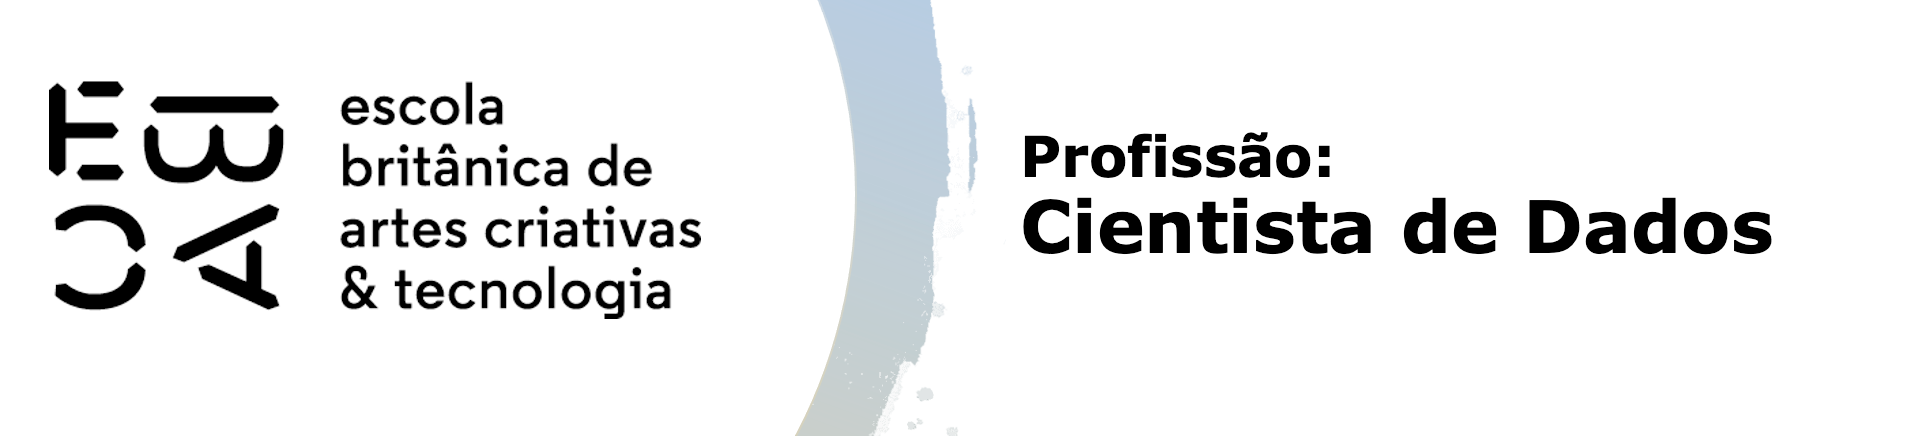

# Tarefa II

Neste projeto, estamos construindo um credit scoring para cartão de crédito, em um desenho amostral com 15 safras, e utilizando 12 meses de performance.

Carregue a base de dados ```credit_scoring.ftr```.

In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import pickle
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import pyarrow.feather as feather

# Em vez de pd.read_feather, usamos diretamente a biblioteca pyarrow
df = feather.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


## Amostragem

Separe os três últimos meses como safras de validação *out of time* (oot).

Variáveis:<br>
Considere que a variável ```data_ref``` não é uma variável explicativa, é somente uma variável indicadora da safra, e não deve ser utilizada na modelagem. A variávei ```index``` é um identificador do cliente, e também não deve ser utilizada como covariável (variável explicativa). As restantes podem ser utilizadas para prever a inadimplência, incluindo a renda.


In [15]:
# Carregamento dos dados
df = feather.read_feather('credit_scoring.ftr')

# Conversão de data_ref para datetime
df['data_ref'] = pd.to_datetime(df['data_ref'])

# Identificando os 3 últimos meses para OOT
meses_oot = sorted(df['data_ref'].unique())[-3:]

# Divisão da base
df_oot = df[df['data_ref'].isin(meses_oot)].copy()
df_train = df[~df['data_ref'].isin(meses_oot)].copy()

print(f"Treino: {df_train.shape[0]} linhas")
print(f"OOT (Validação): {df_oot.shape[0]} linhas")

Treino: 600000 linhas
OOT (Validação): 150000 linhas


## Descritiva básica univariada

- Descreva a base quanto ao número de linhas, número de linhas para cada mês em ```data_ref```.
- Faça uma descritiva básica univariada de cada variável. Considere as naturezas diferentes: qualitativas e quantitativas.

In [16]:
# Contagem por mês
print("Linhas por data_ref:")
print(df['data_ref'].value_counts().sort_index())

# Separando variáveis por tipo (excluindo index e data_ref)
explicativas = df.drop(columns=['index', 'data_ref', 'mau']).columns
quantitativas = df[explicativas].select_dtypes(include=[np.number]).columns.tolist()
qualitativas = df[explicativas].select_dtypes(exclude=[np.number]).columns.tolist()

# Estatística Univariada - Quantitativas
print("\nDescritiva Quantitativas:")
display(df[quantitativas].describe().T)

# Estatística Univariada - Qualitativas
for col in qualitativas:
    print(f"\nDistribuição da variável: {col}")
    print(df[col].value_counts(normalize=True) * 100)

Linhas por data_ref:
data_ref
2015-01-01    50000
2015-02-01    50000
2015-03-01    50000
2015-04-01    50000
2015-05-01    50000
2015-06-01    50000
2015-07-01    50000
2015-08-01    50000
2015-09-01    50000
2015-10-01    50000
2015-11-01    50000
2015-12-01    50000
2016-01-01    50000
2016-02-01    50000
2016-03-01    50000
Name: count, dtype: int64

Descritiva Quantitativas:


,count,mean,std,min,25%,50%,75%,max
qtd_filhos,750000.0,0.433251,0.739379,0.000000,0.000000,0.000000,1.000000,1.400000e+01
idade,750000.0,43.804733,11.229868,22.000000,34.000000,43.000000,53.000000,6.800000e+01
tempo_emprego,624043.0,7.748574,6.687455,0.117808,3.049315,6.046575,10.183562,4.290685e+01
qt_pessoas_residencia,750000.0,2.212241,0.903428,1.000000,2.000000,2.000000,3.000000,1.500000e+01
renda,750000.0,23238.544747,79106.013795,107.670000,3467.700000,7861.820000,18318.280000,4.083986e+06



Distribuição da variável: sexo
sexo
F    67.277333
M    32.722667
Name: proportion, dtype: float64

Distribuição da variável: posse_de_veiculo
posse_de_veiculo
N    61.060533
S    38.939467
Name: proportion, dtype: float64

Distribuição da variável: posse_de_imovel
posse_de_imovel
S    67.158933
N    32.841067
Name: proportion, dtype: float64

Distribuição da variável: tipo_renda
tipo_renda
Assalariado         51.432000
Empresário          23.028267
Pensionista         16.835333
Servidor público     8.656267
Bolsista             0.048133
Name: proportion, dtype: float64

Distribuição da variável: educacao
educacao
Médio                  67.578133
Superior completo      27.240800
Superior incompleto     3.929467
Fundamental             1.143333
Pós graduação           0.108267
Name: proportion, dtype: float64

Distribuição da variável: estado_civil
estado_civil
Casado      70.196267
Solteiro    12.221200
União        7.691333
Separado     5.676133
Viúvo        4.215067
Name: proportion

## Descritiva bivariada

Faça uma análise descritiva bivariada de cada variável

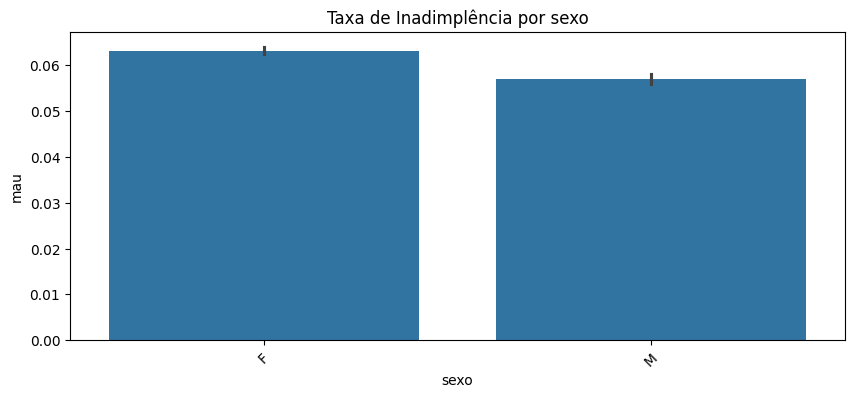

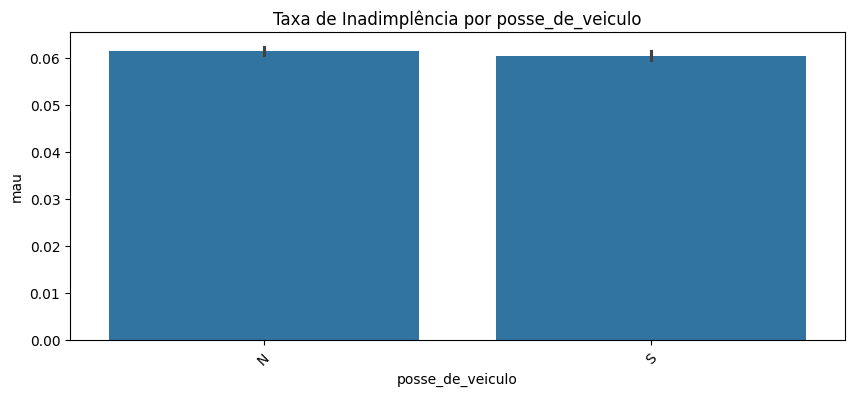

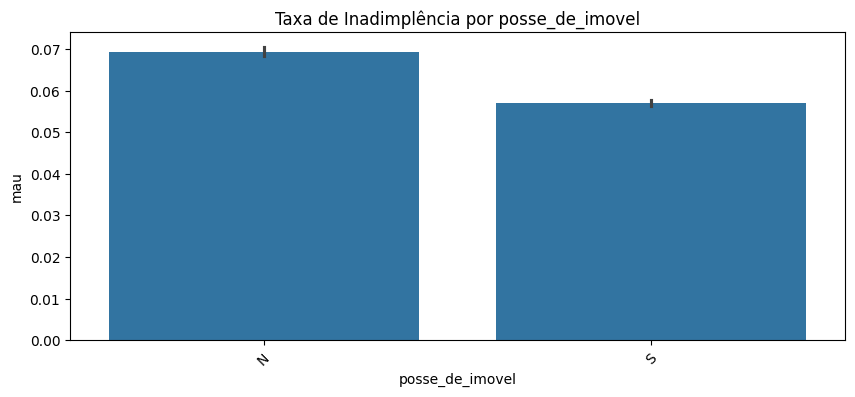

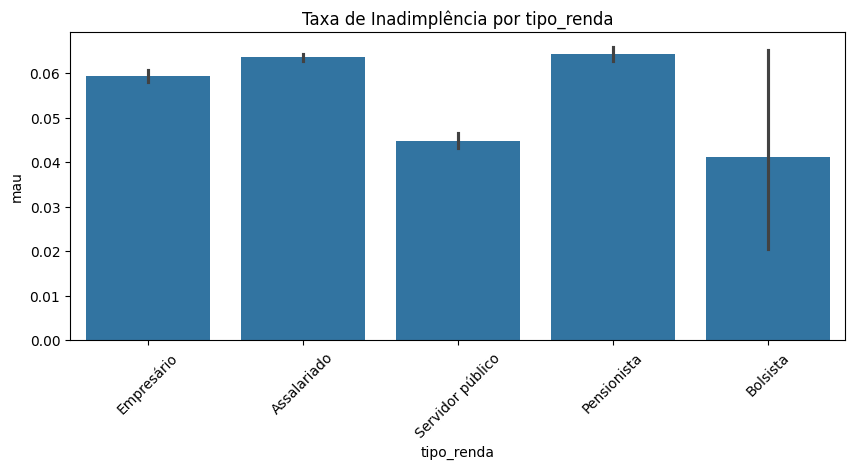

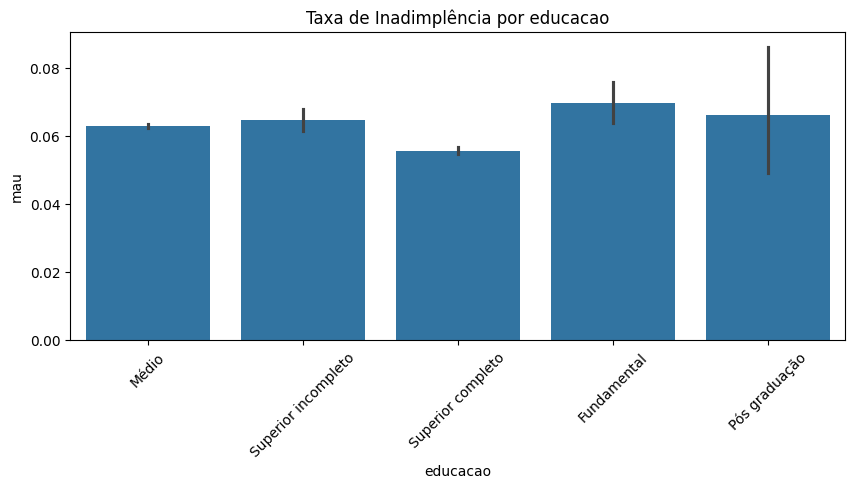

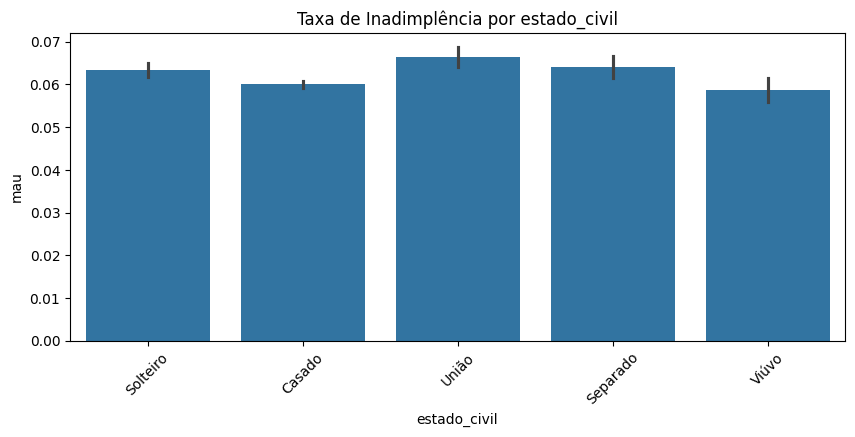

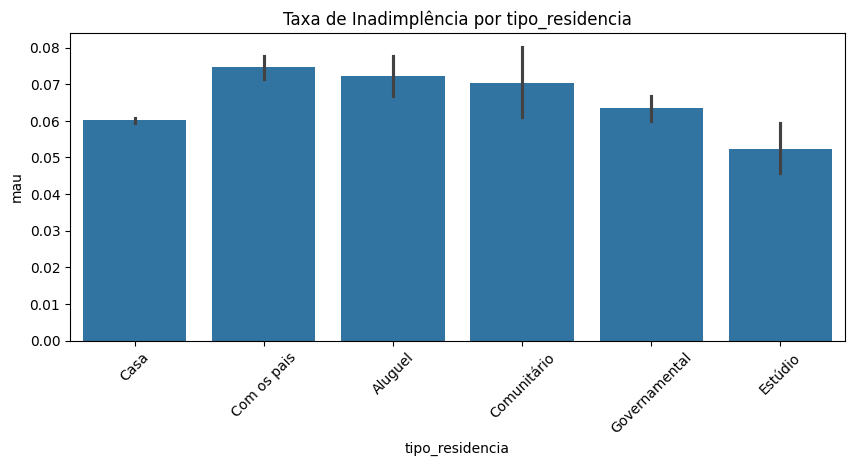

In [17]:
# Exemplo de análise bivariada para qualitativas (Taxa de inadimplência por categoria)
for col in qualitativas:
    plt.figure(figsize=(10, 4))
    sns.barplot(x=col, y='mau', data=df_train)
    plt.title(f'Taxa de Inadimplência por {col}')
    plt.xticks(rotation=45)
    plt.show()

## Desenvolvimento do modelo

Desenvolva um modelo de *credit scoring* através de uma regressão logística.

- Trate valores missings e outliers
- Trate 'zeros estruturais'
- Faça agrupamentos de categorias conforme vimos em aula
- Proponha uma equação preditiva para 'mau'
- Caso hajam categorias não significantes, justifique

In [18]:
# Definindo X e y
X_train = df_train.drop(columns=['index', 'data_ref', 'mau'])
y_train = df_train['mau'].astype(int)

# 1. Tratamento de Outliers (Função customizada ou via Winsorização simples)
# Para simplificar no pipeline, usaremos StandardScaler, mas outliers 
# severos devem ser tratados no DF antes ou via FunctionTransformer.

# 2. Pipeline de Numéricas (Imputer + Escalonamento + PCA)
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('pca', PCA(n_components=5))
])

# 3. Pipeline de Categóricas (Imputer + OneHot)
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combinando no ColumnTransformer
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, quantitativas),
    ('cat', cat_transformer, qualitativas)
])

# Pipeline Final
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression())
])

model_pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=5))]),
                                                  ['qtd_filhos', 'idade',
                                                   'tempo_emprego',
                                                   'qt_pessoas_residencia',
                                                   'renda']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(fill_value='missing',
                                                                                 strategy='constant')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['sexo', 'posse_de_veiculo',
                                                   'posse_de_imovel',
                                                   'tipo_renda', 'educacao',
                                                   'estado_civil',
                                                   'tipo_residencia'])])),
                ('classifier', LogisticRegression())])

## Avaliação do modelo

Avalie o poder discriminante do modelo pelo menos avaliando acurácia, KS e Gini.

Avalie estas métricas nas bases de desenvolvimento e *out of time*.

In [19]:
from sklearn.metrics import accuracy_score, roc_auc_score

def avalia_modelo(modelo, X, y, label):
    probs = modelo.predict_proba(X)[:, 1]
    preds = modelo.predict(X)
    
    auc = roc_auc_score(y, probs)
    gini = 2 * auc - 1
    acc = accuracy_score(y, preds)
    
    print(f"--- Métricas {label} ---")
    print(f"Acurácia: {acc:.4f}")
    print(f"Gini: {gini:.4f}")
    print(f"AUC: {auc:.4f}\n")

# Preparação do OOT
X_oot = df_oot.drop(columns=['index', 'data_ref', 'mau'])
y_oot = df_oot['mau'].astype(int)

avalia_modelo(model_pipeline, X_train, y_train, "Treino")
avalia_modelo(model_pipeline, X_oot, y_oot, "Out of Time")

--- Métricas Treino ---
Acurácia: 0.9389
Gini: 0.5306
AUC: 0.7653

--- Métricas Out of Time ---
Acurácia: 0.8533
Gini: 0.4445
AUC: 0.7222



# a - Criar um pipeline utilizando o sklearn pipeline para o preprocessamento 

## Pré processamento

### Substituição de nulos (nans)

Existe nulos na base? é dado numérico ou categórico? qual o valor de substituição? média? valor mais frequente? etc

In [20]:
# 1. Verificando a existência de nulos
nulos = df_train.isnull().sum()
print("Quantidade de nulos por variável:")
print(nulos[nulos > 0])

# 2. Identificando o tipo de dado das variáveis com nulos
# Geralmente, em bases de crédito, 'tempo_emprego' possui nulos (numérica)

Quantidade de nulos por variável:
tempo_emprego    100875
dtype: int64


### Remoção de outliers

Como identificar outlier? Substituir o outlier por algum valor? Remover a linha?

A técnica mais comum e robusta para dados estruturados (como renda e idade) é o Método do Intervalo Interquartil (IQR).

- **Calculamos o primeiro quartil ($Q1$ - 25%) e o terceiro quartil ($Q3$ - 75%).**

- **O $IQR$ é a diferença: $IQR = Q3 - Q1$.**

- **Qualquer valor abaixo de $Q1 - 1.5 \times IQR$ ou acima de $Q3 + 1.5 \times IQR$ é considerado um outlier.**

In [24]:
def trata_outliers(df, colunas):
    df_copy = df.copy()
    for col in colunas:
        Q1 = df_copy[col].quantile(0.25)
        Q3 = df_copy[col].quantile(0.75)
        IQR = Q3 - Q1
        
        limite_inferior = Q1 - 1.5 * IQR
        limite_superior = Q3 + 1.5 * IQR
        
        # Fazendo o Capping (Substituição)
        df_copy[col] = df_copy[col].clip(lower=limite_inferior, upper=limite_superior)
        
    return df_copy

# Exemplo de uso antes de entrar no Pipeline do Sklearn
colunas_numericas = ['idade', 'tempo_emprego', 'renda', 'qt_pessoas_residencia']
df_train_limpo = trata_outliers(df_train, colunas_numericas)

### Seleção de variáveis

Qual tipo de técnica? Boruta? Feature importance? 

**Para o Pipeline do Sklearn (Item a), recomendo o SelectFromModel com Random Forest. Ele é robusto e automatizado**

In [25]:
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# Adicionando ao seu pipeline
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42))

# No pipeline completo:
# pipeline = Pipeline([
#     ('pre_process', preprocessamento),
#     ('feature_selection', selector),  <-- A seleção acontece aqui
#     ('model', LogisticRegression())
# ])

### Redução de dimensionalidade (PCA)

Aplicar PCA para reduzir a dimensionalidade para 5

In [26]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, FunctionTransformer # <--- Importante
from sklearn.decomposition import PCA

# Certifique-se de que a função 'outlier_treatment' foi definida em uma célula anterior
def outlier_treatment(X):
    import pandas as pd
    import numpy as np
    X = pd.DataFrame(X).copy()
    for col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        X[col] = np.clip(X[col], lim_inf, lim_sup)
    return X

# Agora o Pipeline funcionará sem o erro de NameError
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')), 
    ('outliers', FunctionTransformer(outlier_treatment)), 
    ('scaler', StandardScaler()), 
    ('pca', PCA(n_components=5))
])

### Criação de dummies

Aplicar o get_dummies() ou onehotencoder() para transformar colunas catégoricas do dataframe em colunas de 0 e 1. 
- sexo
- posse_de_veiculo
- posse_de_imovel
- tipo_renda
- educacao
- estado_civil
- tipo_residencia

In [27]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Lista de variáveis solicitadas no seu exercício
colunas_categoricas = [
    'sexo', 
    'posse_de_veiculo', 
    'posse_de_imovel', 
    'tipo_renda', 
    'educacao', 
    'estado_civil', 
    'tipo_residencia'
]

# Configurando o Encoder
# drop='first' remove a primeira categoria para evitar redundância
encoder = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

# Integrando no ColumnTransformer (parte do seu Pipeline do item 'a')
# Isso aplicará o OneHot apenas nas colunas da lista acima
preprocessamento = ColumnTransformer(transformers=[
    ('cat', encoder, colunas_categoricas)
], remainder='passthrough') # Mantém as outras colunas (como as numéricas)

### Pipeline 

Crie um pipeline contendo essas funções.

preprocessamento()
- substituicao de nulos
- remoção outliers
- PCA
- Criação de dummy de pelo menos 1 variável (posse_de_veiculo)

In [28]:
# 1. Definição da Função de Remoção de Outliers (Capping via IQR)
def outlier_treatment(X):
    X = pd.DataFrame(X).copy()
    for col in X.columns:
        Q1 = X[col].quantile(0.25)
        Q3 = X[col].quantile(0.75)
        IQR = Q3 - Q1
        lim_inf = Q1 - 1.5 * IQR
        lim_sup = Q3 + 1.5 * IQR
        X[col] = np.clip(X[col], lim_inf, lim_sup)
    return X

# 2. Definição das colunas por tipo (Baseado no seu arquivo)
# Colunas quantitativas para: Nulos -> Outliers -> Escalonamento -> PCA
features_numericas = ['idade', 'tempo_emprego', 'qt_pessoas_residencia', 'renda', 'qtd_filhos']

# Coluna para Dummy (conforme solicitado: pelo menos posse_de_veiculo)
# Vou incluir as outras solicitadas anteriormente para um modelo completo
features_categoricas = ['posse_de_veiculo', 'sexo', 'posse_de_imovel', 'tipo_renda', 
                        'educacao', 'estado_civil', 'tipo_residencia']

# 3. Criação do Pipeline de Processamento Numérico
num_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),       # Substituição de Nulos
    ('outliers', FunctionTransformer(outlier_treatment)), # Remoção de Outliers
    ('scaler', StandardScaler()),                        # Escalonamento para o PCA
    ('pca', PCA(n_components=5))                         # Redução de dimensionalidade
])

# 4. Criação do Pipeline de Processamento Categórico (Dummies)
cat_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')), # Substituição de Nulos
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore')) # Criação de Dummies
])

# 5. Agrupamento no ColumnTransformer (A função preprocessamento())
preprocessamento = ColumnTransformer(transformers=[
    ('num', num_pipeline, features_numericas),
    ('cat', cat_pipeline, features_categoricas)
])

# 6. Pipeline Final (Preprocessamento + Modelo)
pipeline_final = Pipeline(steps=[
    ('preprocessamento', preprocessamento),
    ('modelo', LogisticRegression())
])

# Exibindo o Pipeline
from sklearn import set_config
set_config(display='diagram')
pipeline_final

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('outliers',
                                                                   FunctionTransformer(func=<function outlier_treatment at 0x000001BF7A328AF0>)),
                                                                  ('scaler',
                                                                   StandardScaler()),
                                                                  ('pca',
                                                                   PCA(n_components=5))]),
                                                  ['idade', 'tempo_emprego',
                                                   'qt_pessoas_residencia',
                                                   'renda', 'qtd_filhos']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['posse_de_veiculo', 'sexo',
                                                   'posse_de_imovel',
                                                   'tipo_renda', 'educacao',
                                                   'estado_civil',
                                                   'tipo_residencia'])])),
                ('modelo', LogisticRegression())])

In [8]:
# 2. Separar as safras (OOT)
safras_ordenadas = sorted(df['data_ref'].unique())
safras_oot = safras_ordenadas[-3:]
safras_dev = safras_ordenadas[:-3]

df_dev = df[df['data_ref'].isin(safras_dev)].copy()

# 3. Criar as variáveis explicativas (Aqui nasce o X_dev!)
target = 'mau'
vars_remover = ['data_ref', 'index', target]
features = [col for col in df.columns if col not in vars_remover]

X_dev = df_dev[features]
y_dev = df_dev[target].astype(int)

print("X_dev criado com sucesso!")

X_dev criado com sucesso!


In [9]:
# 1. Identificar os tipos de colunas para o pré-processamento automático
# (Certifique-se de que a célula que cria o X_dev já foi executada antes desta!)
colunas_numericas = X_dev.select_dtypes(include=['int64', 'float64']).columns.tolist()
colunas_categoricas = X_dev.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

# 2. Configurar os transformadores
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# 3. Combinar os tratamentos de acordo com o tipo de coluna
preprocessor = ColumnTransformer(transformers=[
    ('num', num_transformer, colunas_numericas),
    ('cat', cat_transformer, colunas_categoricas)
])

# 4. Criar o pipeline unindo o Pré-processamento + Modelo de Regressão Logística
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(random_state=42, max_iter=1000))
])

# 5. Treinar o modelo
model_pipeline.fit(X_dev, y_dev)
print("Pipeline e Modelo criados e treinados com sucesso!")

Pipeline e Modelo criados e treinados com sucesso!


In [10]:
nome_arquivo = 'model_final.pkl'

# Abrir o arquivo em modo de escrita binária ('wb') e salvar o pipeline inteiro
with open(nome_arquivo, 'wb') as arquivo:
    pickle.dump(model_pipeline, arquivo)

print(f"\n[OK] Arquivo pickle salvo com sucesso sob o nome: '{nome_arquivo}'")


[OK] Arquivo pickle salvo com sucesso sob o nome: 'model_final.pkl'


# b - Pycaret na base de dados 

Utilize o pycaret para pre processar os dados e rodar o modelo **lightgbm**. Faça todos os passos a passos da aula e gere os gráficos finais. E o pipeline de toda a transformação.



In [42]:
from pycaret.classification import *
# Preparando a base: removendo 'index' e convertendo 'data_ref' para não entrar no modelo
df_pycaret = df.drop(columns=['index'])
df_pycaret['data_ref'] = pd.to_datetime(df_pycaret['data_ref'])

# Separação manual para garantir o teste na base OOT (3 últimos meses)
meses_oot = sorted(df_pycaret['data_ref'].unique())[-3:]
df_train_pc = df_pycaret[~df_pycaret['data_ref'].isin(meses_oot)].drop(columns=['data_ref'])
df_oot_pc = df_pycaret[df_pycaret['data_ref'].isin(meses_oot)].drop(columns=['data_ref'])
df


,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
749995,2016-03-01,13689,M,N,S,0,Empresário,Superior completo,Casado,Casa,48,3.038356,2.0,2109.99,False
749996,2016-03-01,7000,F,N,S,0,Pensionista,Médio,Solteiro,Casa,65,NaN,1.0,1389.39,False
749997,2016-03-01,14023,M,S,N,2,Assalariado,Médio,Casado,Casa,43,10.375342,4.0,649.06,True
749998,2016-03-01,2396,F,N,S,0,Assalariado,Médio,Viúvo,Casa,56,13.780822,1.0,4216.72,True


In [31]:
# Configurando o ambiente
exp_setup = setup(
    data = df_train_pc, 
    target = 'mau',
    
    # Pré-processamento
    imputation_type = 'simple',
    numeric_imputation = 'median',
    categorical_imputation = 'mode',
    
    # Outliers
    remove_outliers = True,
    outliers_threshold = 0.05,
    
    # Redução de Dimensionalidade (PCA)
    pca = True,
    pca_method = 'linear',
    pca_components = 5,
    
    # Variáveis Categóricas (Dummies automáticos)
    categorical_features = ['sexo', 'posse_de_veiculo', 'posse_de_imovel', 
                            'tipo_renda', 'educacao', 'estado_civil', 'tipo_residencia'],
    
    session_id = 123,
    normalize = True # Recomendado ao usar PCA
)

,Description,Value
0,Session id,123
1,Target,mau
2,Target type,Binary
3,Original data shape,"(600000, 13)"
4,Transformed data shape,"(579018, 6)"
5,Transformed train set shape,"(399018, 6)"
6,Transformed test set shape,"(180000, 6)"
7,Numeric features,5
8,Categorical features,7
9,Rows with missing values,16.8%


In [32]:
# Criando o modelo LightGBM
lgbm = create_model('lightgbm')

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.9389,0.6808,0.0000,0.0000,0.0000,0.0000,0.0000
1,0.9389,0.6794,0.0000,0.0000,0.0000,0.0000,0.0000
2,0.9389,0.6691,0.0000,0.0000,0.0000,0.0000,0.0000
3,0.9389,0.6857,0.0000,0.0000,0.0000,0.0000,0.0000
4,0.9389,0.6809,0.0000,0.0000,0.0000,0.0000,0.0000
5,0.9389,0.6784,0.0000,0.0000,0.0000,0.0000,0.0000
6,0.9389,0.6853,0.0004,0.2500,0.0008,0.0006,0.0077
7,0.9389,0.6866,0.0000,0.0000,0.0000,0.0000,0.0000
8,0.9389,0.6766,0.0000,0.0000,0.0000,0.0000,0.0000


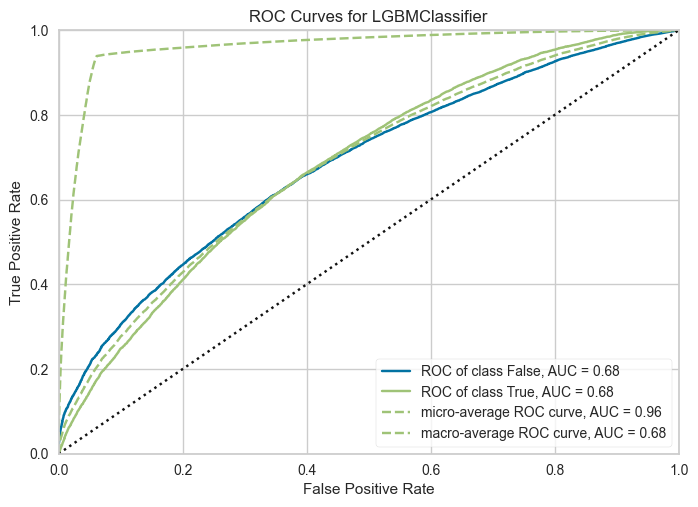

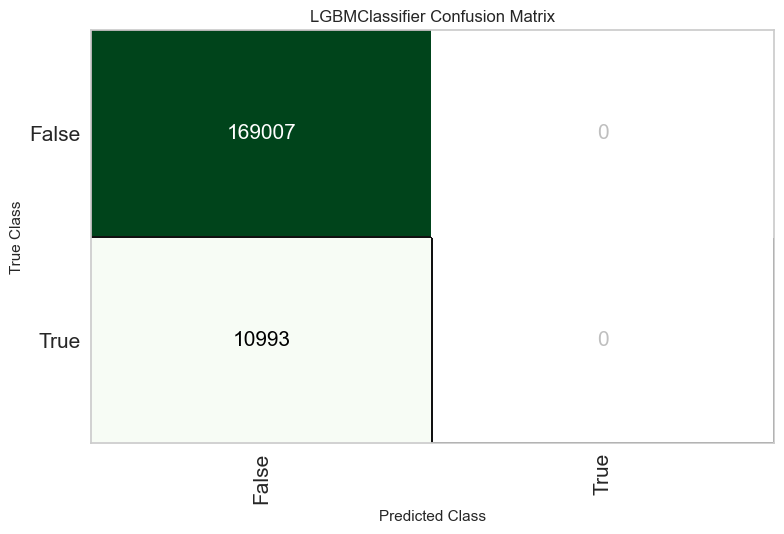

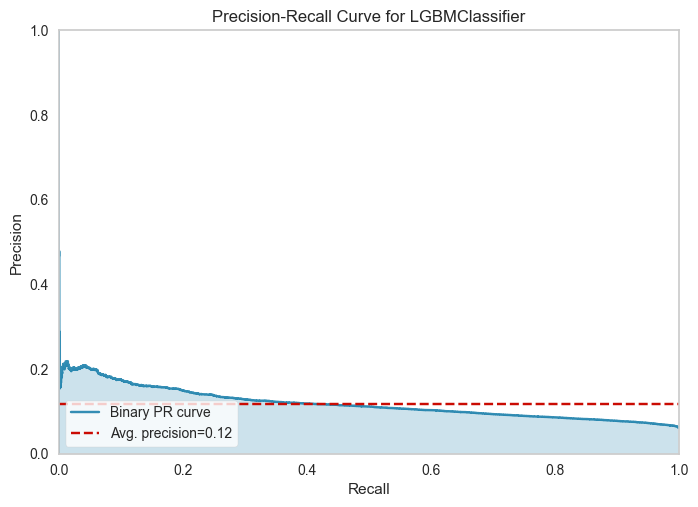

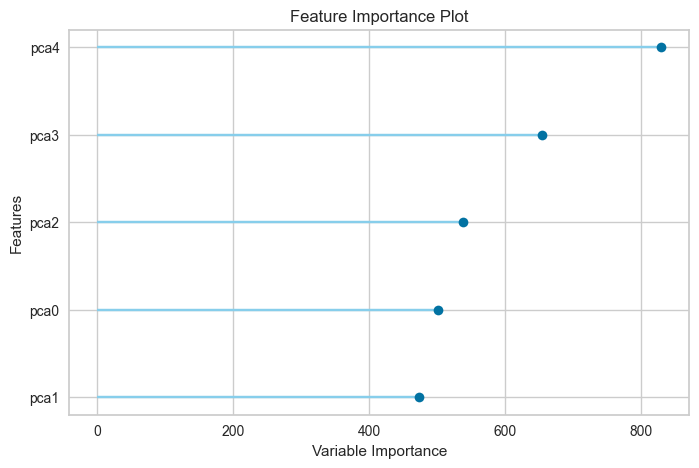

interactive(children=(ToggleButtons(description='Plot Type:', icons=('',), options=(('Pipeline Plot', 'pipelin…

In [33]:
# Gráfico de AUC-ROC (Poder discriminante)
plot_model(lgbm, plot='auc')

# Matriz de Confusão
plot_model(lgbm, plot='confusion_matrix')

# Curva de Precisão-Recall
plot_model(lgbm, plot='pr')

# Importância das Variáveis (Feature Importance)
# Nota: Como usamos PCA, ele mostrará a importância dos Componentes Principais
plot_model(lgbm, plot='feature')

# Avaliação interativa (abre um painel com várias métricas)
evaluate_model(lgbm)

In [34]:
# Predição na base OOT
predicoes_oot = predict_model(lgbm, data=df_oot_pc)
print(predicoes_oot.head())

# Exibindo o Pipeline de toda a transformação
# O PyCaret gera um pipeline que inclui desde a imputação até o modelo final
pipeline_transformacao = get_config('pipeline')
print("\n--- Pipeline de Transformação Completo ---")
print(pipeline_transformacao)

# Salvando o modelo e o pipeline
save_model(lgbm, 'modelo_final_lgbm_credit')

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
0,Light Gradient Boosting Machine,0.8533,0.6523,0.0000,0.0000,0.0000,0.0000,0.0000


       sexo posse_de_veiculo posse_de_imovel  qtd_filhos   tipo_renda  \
600000    F                S               S           2  Assalariado   
600001    F                N               S           0  Assalariado   
600002    M                S               S           1  Assalariado   
600003    F                N               S           1  Assalariado   
600004    M                S               N           0  Assalariado   

                 educacao estado_civil tipo_residencia  idade  tempo_emprego  \
600000  Superior completo       Casado            Casa     38       7.383562   
600001              Médio       Casado            Casa     55       8.471232   
600002              Médio        União            Casa     39       8.884932   
600003              Médio        União     Com os pais     31       1.794520   
600004              Médio       Casado            Casa     27       7.019178   

        qt_pessoas_residencia         renda    mau  prediction_label  \
600000  

(Pipeline(memory=Memory(location=None),
          steps=[('numerical_imputer',
                  TransformerWrapper(exclude=None,
                                     include=['qtd_filhos', 'idade',
                                              'tempo_emprego',
                                              'qt_pessoas_residencia', 'renda'],
                                     transformer=SimpleImputer(add_indicator=False,
                                                               copy=True,
                                                               fill_value=None,
                                                               keep_empty_features=False,
                                                               missing_values=nan,
                                                               strategy='median'))),
                 ('categorical_imputer',
                  TransformerW...
                  LGBMClassifier(boosting_type='gbdt', class_weight=None,
            

In [39]:
df = feather.read_feather('credit_scoring.ftr')
df.head()

,data_ref,index,sexo,posse_de_veiculo,posse_de_imovel,qtd_filhos,tipo_renda,educacao,estado_civil,tipo_residencia,idade,tempo_emprego,qt_pessoas_residencia,renda,mau
0,2015-01-01,5733,F,N,N,0,Empresário,Médio,Solteiro,Casa,43,6.873973,1.0,2515.39,False
1,2015-01-01,727,F,S,S,0,Assalariado,Médio,Casado,Casa,35,4.526027,2.0,3180.19,False
2,2015-01-01,6374,F,N,N,2,Assalariado,Médio,Casado,Casa,31,0.243836,4.0,1582.29,False
3,2015-01-01,9566,F,N,N,0,Assalariado,Médio,Casado,Casa,54,12.772603,2.0,13721.17,False
4,2015-01-01,9502,F,S,N,0,Assalariado,Superior incompleto,Solteiro,Casa,31,8.432877,1.0,2891.08,False


In [37]:
from pycaret.classification import *
models()

,Name,Reference,Turbo
ID,,,
lr,Logistic Regression,sklearn.linear_model._logistic.LogisticRegression,True
knn,K Neighbors Classifier,sklearn.neighbors._classification.KNeighborsCl...,True
nb,Naive Bayes,sklearn.naive_bayes.GaussianNB,True
dt,Decision Tree Classifier,sklearn.tree._classes.DecisionTreeClassifier,True
svm,SVM - Linear Kernel,sklearn.linear_model._stochastic_gradient.SGDC...,True
rbfsvm,SVM - Radial Kernel,sklearn.svm._classes.SVC,False
gpc,Gaussian Process Classifier,sklearn.gaussian_process._gpc.GaussianProcessC...,False
mlp,MLP Classifier,sklearn.neural_network._multilayer_perceptron....,False
ridge,Ridge Classifier,sklearn.linear_model._ridge.RidgeClassifier,True


In [5]:
# xxx = create_model('xxx')

# Projeto Final

1. Subir no GITHUB todos os jupyter notebooks/códigos que você desenvolveu nesse ultimo módulo
1. Gerar um arquivo python (.py) com todas as funções necessárias para rodar no streamlit a escoragem do arquivo de treino
    - Criar um .py
    - Criar um carregador de csv no streamlit 
    - Subir um csv no streamlit 
    - Criar um pipeline de pré processamento dos dados
    - Utilizar o modelo treinado para escorar a base 
        - nome_arquivo = 'model_final.pkl'
1. Gravar um vídeo da tela do streamlit em funcionamento (usando o próprio streamlit (temos aula disso) ou qlqr outra forma de gravação).
1. Subir no Github o vídeo de funcionamento da ferramenta como README.md.
1. Subir no Github os códigos desenvolvidos. 
1. Enviar links do github para o tutor corrigir.